=== MINIMAL FAST RUL TRAINING ===
Using 1 file(s) for fast testing: ['3_1649063820_1649069700_fast.csv']
Processing file: 3_1649063820_1649069700_fast.csv
Signal shape: (24889344, 2)
Created 100 windows of size (512, 2)
Final data shapes: X=(100, 512, 2), y=(100,)
Normalizing input features...
Train: X=(80, 512, 2), y=(80,)
Test: X=(20, 512, 2), y=(20,)
Building tiny model...
Signal shape: (24889344, 2)
Created 100 windows of size (512, 2)
Final data shapes: X=(100, 512, 2), y=(100,)
Normalizing input features...
Train: X=(80, 512, 2), y=(80,)
Test: X=(20, 512, 2), y=(20,)
Building tiny model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 512, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 510, 8)         │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 127, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217 (868.00 B)

 Trainable params: 217 (868.00 B)

 Non-trainable params: 0 (0.00 B)

Training (should be very fast)...
Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.8725 - mae: 0.8725 - val_loss: 0.3235 - val_mae: 0.3235
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.8725 - mae: 0.8725 - val_loss: 0.3235 - val_mae: 0.3235
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7615 - mae: 0.7615 - val_loss: 0.2312 - val_mae: 0.2312
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7615 - mae: 0.7615 - val_loss: 0.2312 - val_mae: 0.2312
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6365 - mae: 0.6365 - val_loss: 0.1398 - val_mae: 0.1398
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6365 - mae: 0.6365 - val_loss: 0.1398 - val_mae: 0.1398
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x3521480d0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due

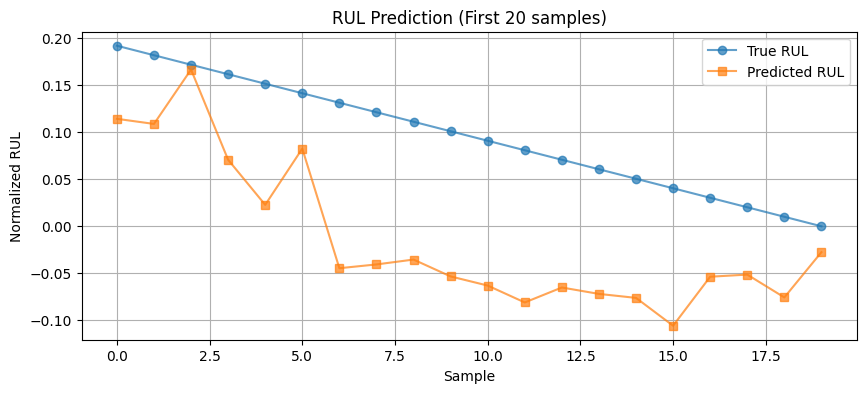

Fast training completed!


In [5]:
import os
import sys
import gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import layers, models
import importlib

# === Minimal Fast Training Approach ===
print("=== MINIMAL FAST RUL TRAINING ===")

# === Append src path ===
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# === Reload updated modules ===
if 'src.utils.preprocessing' in sys.modules:
    importlib.reload(sys.modules['src.utils.preprocessing'])

from src.utils.preprocessing import load_fast_csv, window_data, parse_filename

# === Load ONE file for quick testing ===
fast_folder = "../data/SMARTPDM_dataset.csv"
files = [f for f in os.listdir(fast_folder) if f.endswith("_fast.csv")][:1]  # Just ONE file
print(f"Using {len(files)} file(s) for fast testing: {files}")

# Load and process the single file
fname = files[0]
print(f"Processing file: {fname}")

signal = load_fast_csv(os.path.join(fast_folder, fname))
print(f"Signal shape: {signal.shape}")

# Create a small number of windows
windows = window_data(signal, window_size=512)[:100]  # Smaller windows, only 100 of them
print(f"Created {len(windows)} windows of size {windows[0].shape}")

# Generate simple RUL labels
y = np.arange(len(windows) - 1, -1, -1) / (len(windows) - 1)  # Normalized to [0,1]

X = np.array(windows)
print(f"Final data shapes: X={X.shape}, y={y.shape}")

# === Normalize input features ===
from sklearn.preprocessing import StandardScaler

print("Normalizing input features...")
X_flat = X.reshape(-1, 2)  # Collapse time dimension
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
X = X_scaled.reshape(X.shape)


# === Train/test split ===
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test: X={X_test.shape}, y={y_test.shape}")

# === Ultra-simple model ===
def build_tiny_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(8, kernel_size=3, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(16, activation='relu')(x)
    output = layers.Dense(1)(x)
    model = models.Model(inputs=inputs, outputs=output)
    return model

print("Building tiny model...")
model = build_tiny_model(X_train.shape[1:])
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()

# === Quick training ===
print("Training (should be very fast)...")
history = model.fit(X_train, y_train, epochs=3, batch_size=16, verbose=1, validation_split=0.2)

# === Quick evaluation ===
y_pred = model.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.4f}")

# === Plot ===
plt.figure(figsize=(10,4))
plt.plot(y_test[:20], 'o-', label='True RUL', alpha=0.7)
plt.plot(y_pred[:20], 's-', label='Predicted RUL', alpha=0.7)
plt.title("RUL Prediction (First 20 samples)")
plt.xlabel("Sample")
plt.ylabel("Normalized RUL")
plt.legend()
plt.grid(True)
plt.show()

print("Fast training completed!")